# Student Performance Indicator

## Life Cycle of a Machine Learning Project

1. Understanding the Problem Statement  
2. Data Collection  
3. Data Checks to Perform  
4. Exploratory Data Analysis (EDA)  
5. Data Pre-processing  
6. Model Training  
7. Choosing the Best Model  

---

## 1. Problem Statement

This project aims to understand how a student's performance is affected by various factors such as:
- Gender  
- Ethnicity  
- Parental level of education  
- Lunch type  
- Test preparation course  

The goal is to analyze the impact of these variables on students' exam scores and build a machine learning model to predict performance.

---

## 2. Data Collection

### 2.1 Dataset Source
- **Source:** Kaggle  
- **Link:** https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977  

### 2.2 Dataset Information
- The dataset consists of **1000 rows** and **8 columns**.
- Each row represents a student.
- The columns include demographic information and exam scores.

---

## 3. Import Data and Required Packages

In this step, we import the necessary Python libraries required for data analysis, visualization, and preprocessing.

### Libraries Used:
- **NumPy** – for numerical computations  
- **Pandas** – for data manipulation and analysis  
- **Matplotlib** – for data visualization  
- **Seaborn** – for advanced statistical visualizations  
- **Warnings** – to suppress unnecessary warnings during execution


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

Import csv data as a DataFrame

In [3]:
df=pd.read_csv('data/study.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1000, 8)

## 2.2 Dataset Information

- **Gender:** Sex of the student (Male / Female)
- **Race/Ethnicity:** Ethnic group of the student (Group A, B, C, D, E)
- **Parental Level of Education:** Final education level of the parents
- **Lunch:** Type of lunch before the test (Standard or Free/Reduced)
- **Test Preparation Course:** Completion status of the test preparation course (Completed / Not Completed)
- **Math Score:** Score obtained in mathematics
- **Reading Score:** Score obtained in reading
- **Writing Score:** Score obtained in writing

---

## 3. Data Checkpoints

In this step, we perform basic checks to understand the quality and structure of the dataset.

- Check for missing values
- Check for duplicate values
- Verify data types
- Check the number of unique values in each column
- Review statistical summary of the dataset
- Identify different categories present in categorical columns

---

### 3.1 Check Missing Values

In this section, we check whether the dataset contains any missing or null values that need to be handled before further analysis.


In [6]:
df.isna().sum

<bound method DataFrame.sum of      gender  race_ethnicity  parental_level_of_education  lunch  \
0     False           False                        False  False   
1     False           False                        False  False   
2     False           False                        False  False   
3     False           False                        False  False   
4     False           False                        False  False   
..      ...             ...                          ...    ...   
995   False           False                        False  False   
996   False           False                        False  False   
997   False           False                        False  False   
998   False           False                        False  False   
999   False           False                        False  False   

     test_preparation_course  math_score  reading_score  writing_score  
0                      False       False          False          False  
1                 

### 3.2 Checking duplicate values

In [7]:
df.duplicated().sum()

np.int64(0)

### 3.3 Checking data types

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### 3.4 Checking the no of unique values

In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 3.5 Check staistics of data set

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Insights from Numerical Data

- The mean scores for all subjects are very close to each other, ranging between **66 and 68.05**, indicating a similar overall performance level.
- The standard deviations are also quite similar, ranging between **14.6 and 15.19**, which shows that the variability in scores across subjects is nearly the same.
- The minimum score for **Math** is **0**, indicating that at least one student scored extremely low.
- In comparison, the minimum scores for **Writing** and **Reading** are significantly higher, at **10** and **17** respectively.
- This suggests that students generally perform better in **Reading and Writing** than in **Math**.

---

### 3.6 Exploring the Dataset

In this section, we analyze the dataset to understand:
- The distribution of scores
- Relationships between different features
- Patterns and trends affecting student performance

This exploration helps identify insights that guide data preprocessing and model selection.


In [11]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [12]:
numeric_features=[i for i in df.columns if df[i].dtype!='object']
categorical_features=[i for i in df.columns if df[i].dtype=='object']
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [13]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### 3.7 Adding  colums for " Total score " and " Average  "

In [14]:
df['total score']=df['math_score']+df['reading_score']+df['writing_score']
df['average']=df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [15]:
reading_full=df[df['reading_score']==100]['average'].count()
writing_full=df[df['writing_score']==100]['average'].count()
math_full=df[df['math_score']==100]['average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [16]:
reading_less=df[df['reading_score']<=20]['average'].count()
writing_less=df[df['writing_score']<=20]['average'].count()
math_less=df[df['math_score']<=20]['average'].count()




print(f'Number of students with less than 20 marks in Maths: {math_less}')
print(f'Number of students with less than 20 marks in Writing: {writing_less}')
print(f'Number of students with less than 20 marks in Reading: {reading_less}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


### Insights

- From the above values, it is observed that students have performed the **worst in Mathematics**.
- The **best overall performance** is observed in the **Reading** section.



In [17]:
numeric_features=[i for i in df.columns if df[i].dtype!='object']
categorical_features=[i for i in df.columns if df[i].dtype=='object']
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 5 numerical features : ['math_score', 'reading_score', 'writing_score', 'total score', 'average']

We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


## 4. Exploring Data (Visualization)

In this section, we use visualizations to better understand the distribution and trends in student performance.

---

### 4.1 Visualizing Average Scores to Draw Conclusions

To analyze the distribution of average scores, we use the following visualizations:

- **Histogram**  
  Used to understand the frequency distribution of students' average scores.

- **Kernel Density Estimation (KDE)**  
  Used to observe the smooth probability distribution of average scores and identify overall trends.


<Axes: xlabel='average', ylabel='Count'>

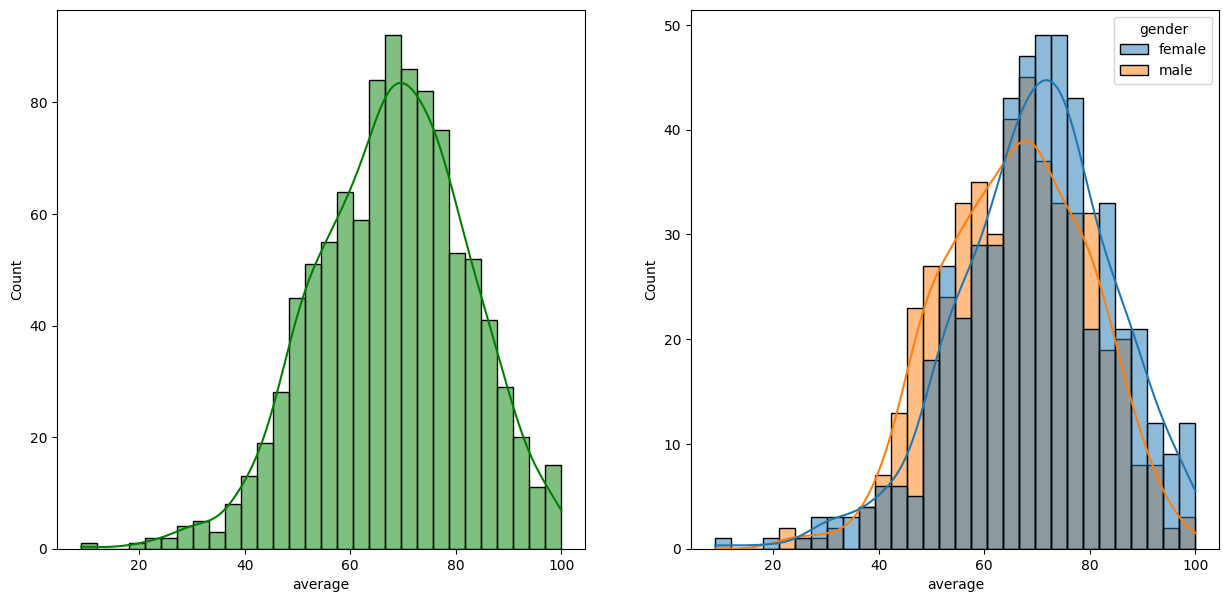

In [18]:
fig,axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender',bins=30)

<Axes: xlabel='total score', ylabel='Count'>

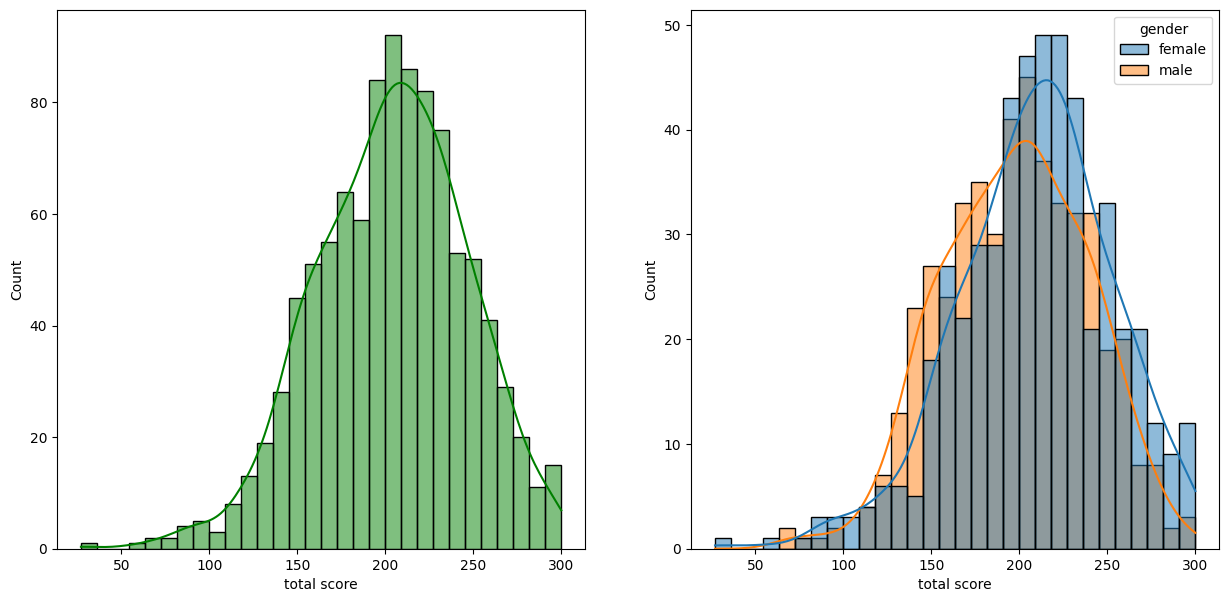

In [19]:
fig,axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='total score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total score',kde=True,hue='gender',bins=30)

##### Female students tends to perform well

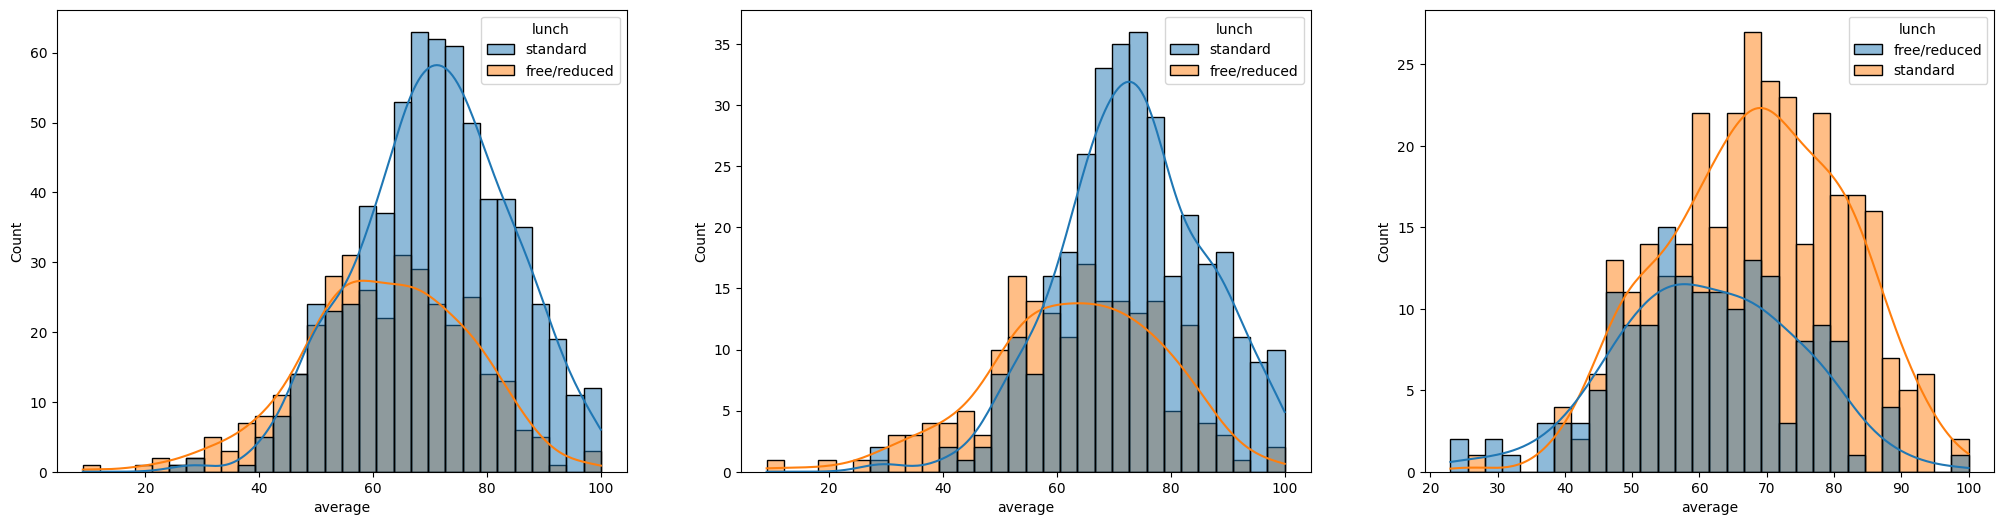

In [20]:
fig,axs=plt.subplots(1,3 ,figsize=(25,6))
plt.subplot(131)
sns.histplot(data=df,x='average',bins=30,kde=True,hue='lunch')
plt.subplot(132)
sns.histplot(data=df[df['gender']=='female'] ,x='average',bins=30,kde=True,hue='lunch')
plt.subplot(133)
sns.histplot(data=df[df['gender']=='male'] ,x='average',bins=30,kde=True,hue='lunch')
plt.show()

## Insights

- Students who receive a **standard lunch** tend to perform better in exams.
- The positive impact of a **standard lunch** on exam performance is observed for **both male and female students**.


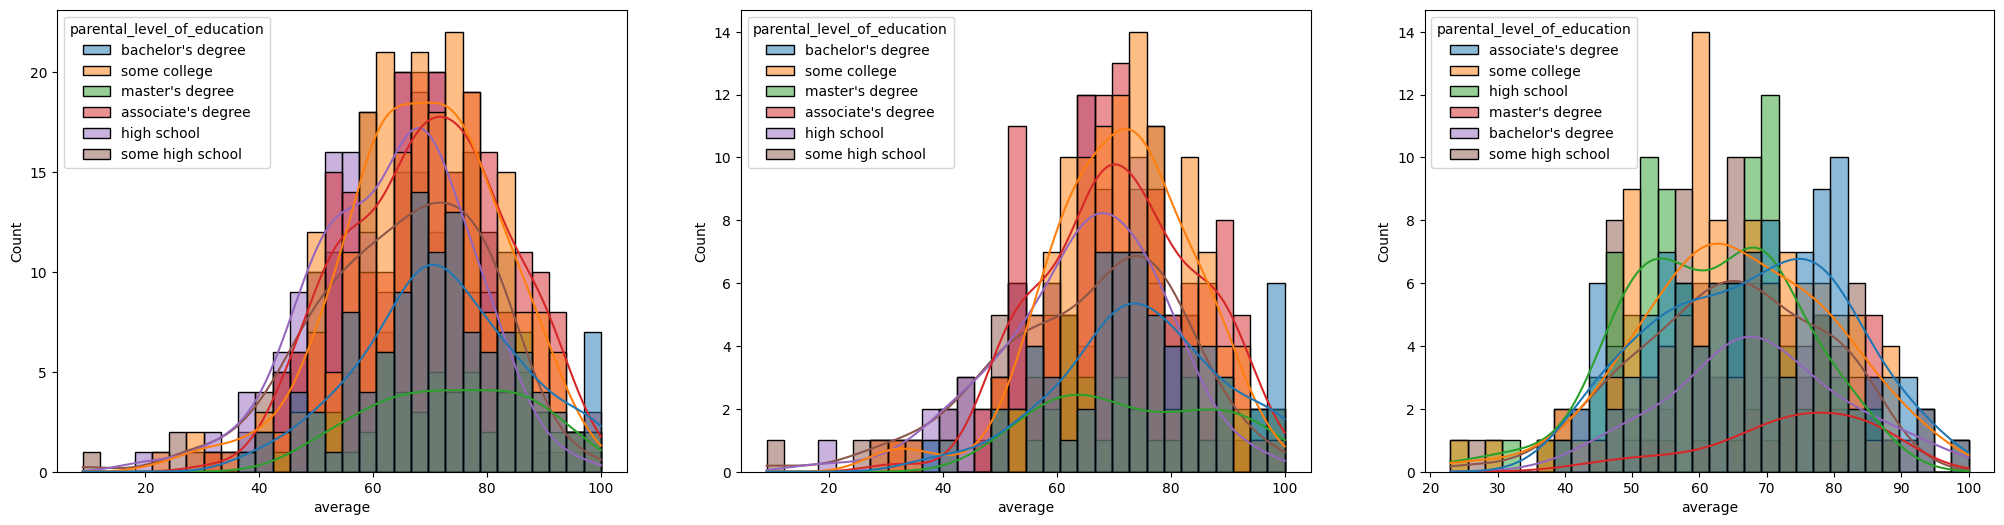

In [21]:
fig,axs=plt.subplots(1,3 ,figsize=(25,6))
plt.subplot(131)
sns.histplot(data=df,x='average',bins=30,kde=True,hue='parental_level_of_education')
plt.subplot(132)
sns.histplot(data=df[df['gender']=='female'] ,x='average',bins=30,kde=True,hue='parental_level_of_education')
plt.subplot(133)
sns.histplot(data=df[df['gender']=='male'] ,x='average',bins=30,kde=True,hue='parental_level_of_education')
plt.show()

### Insights

- In general, **parental level of education does not have a strong impact** on a student’s exam performance.
- The second plot indicates that **male students** whose parents have an **associate’s degree or a master’s degree** tend to perform better in exams.
- From the third plot, it can be observed that **parental education has little to no effect on the exam performance of female students**.


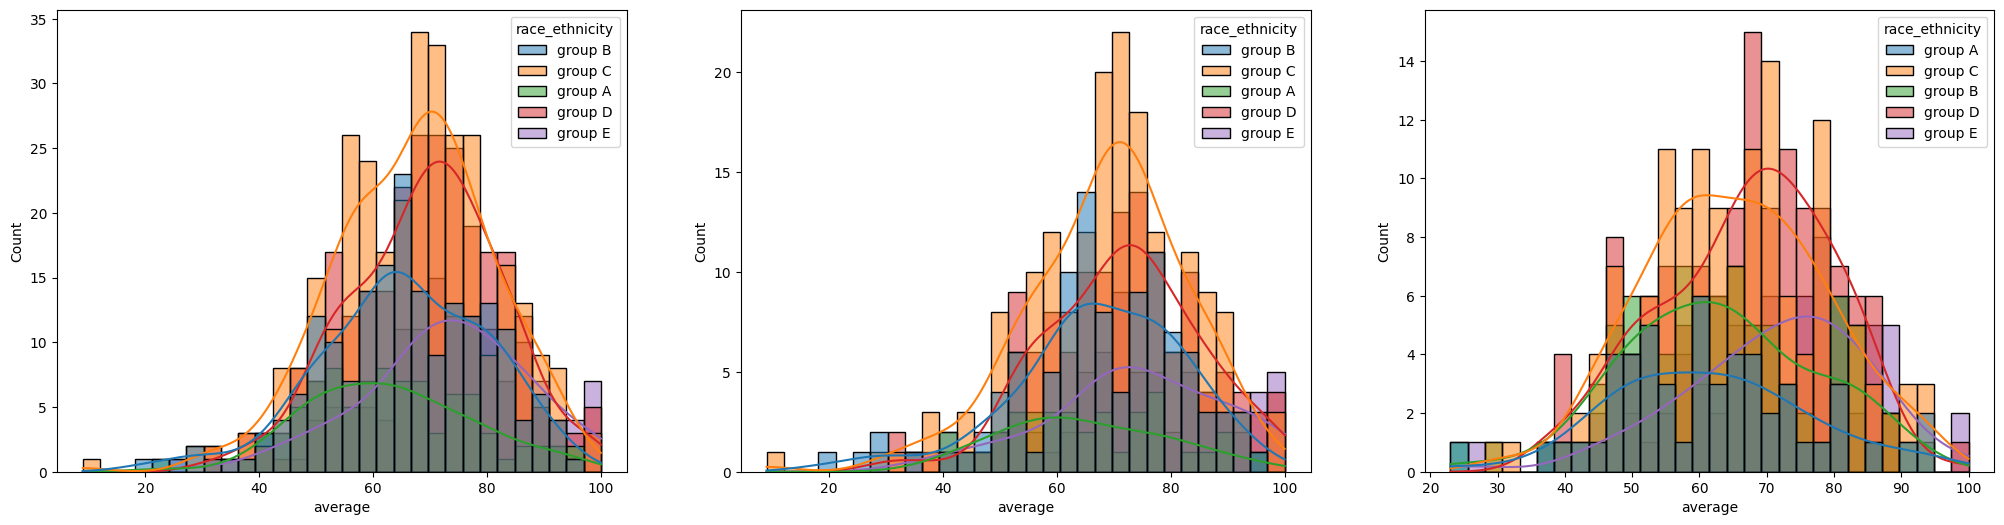

In [22]:
fig,axs=plt.subplots(1,3 ,figsize=(25,6))
plt.subplot(131)
sns.histplot(data=df,x='average',bins=30,kde=True,hue='race_ethnicity')
plt.subplot(132)
sns.histplot(data=df[df['gender']=='female'] ,x='average',bins=30,kde=True,hue='race_ethnicity')
plt.subplot(133)
sns.histplot(data=df[df['gender']=='male'] ,x='average',bins=30,kde=True,hue='race_ethnicity')
plt.show()

### Insights

- Students belonging to **Group A** and **Group B** tend to perform poorly in exams compared to other groups.
- This lower performance among **Group A** and **Group B** students is observed **irrespective of gender**, for both male and female students.


## 4.2 Maximumum score of students in all three subjects


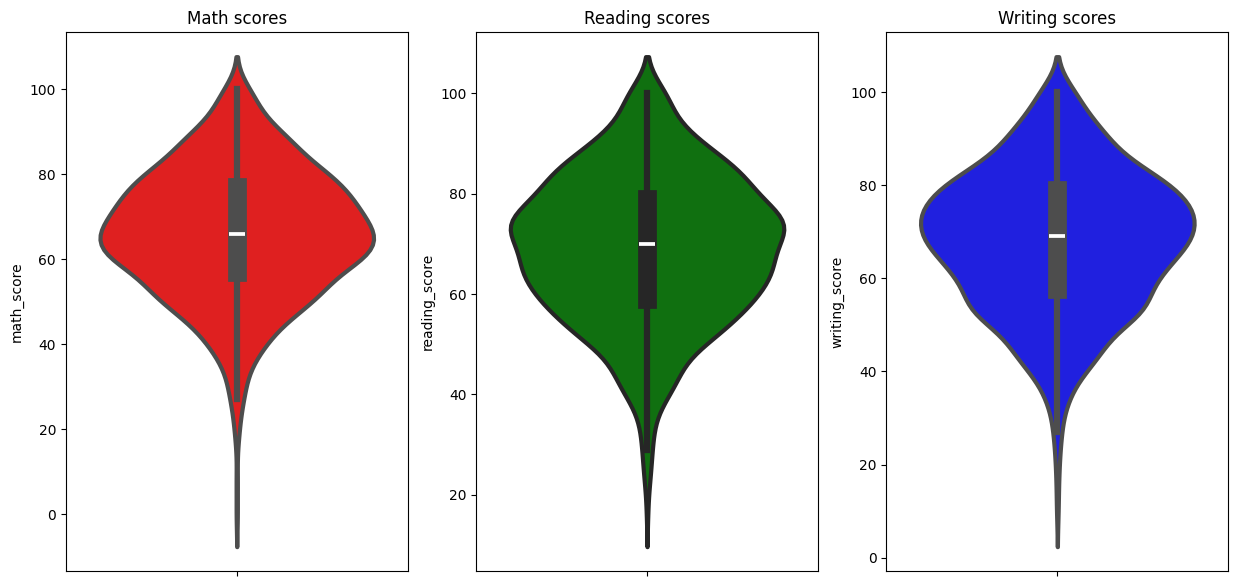

In [23]:
plt.figure(figsize=(15,7))
plt.subplot(1,3,1)
plt.title("Math scores")
sns.violinplot(data=df,y='math_score',color='red',linewidth=3)
plt.subplot(1,3,2)
plt.title("Reading scores") 
sns.violinplot(data=df,y='reading_score',color='green',linewidth=3)
plt.subplot(1,3,3)
plt.title("Writing scores")
sns.violinplot(data=df,y='writing_score',color='blue',linewidth=3)
plt.show()

### Insight.
-   from the above three plots we can clearly obserev that  most of the students score is between 60-80 in maths whereas in reading and writing most of them are socred between 50-80

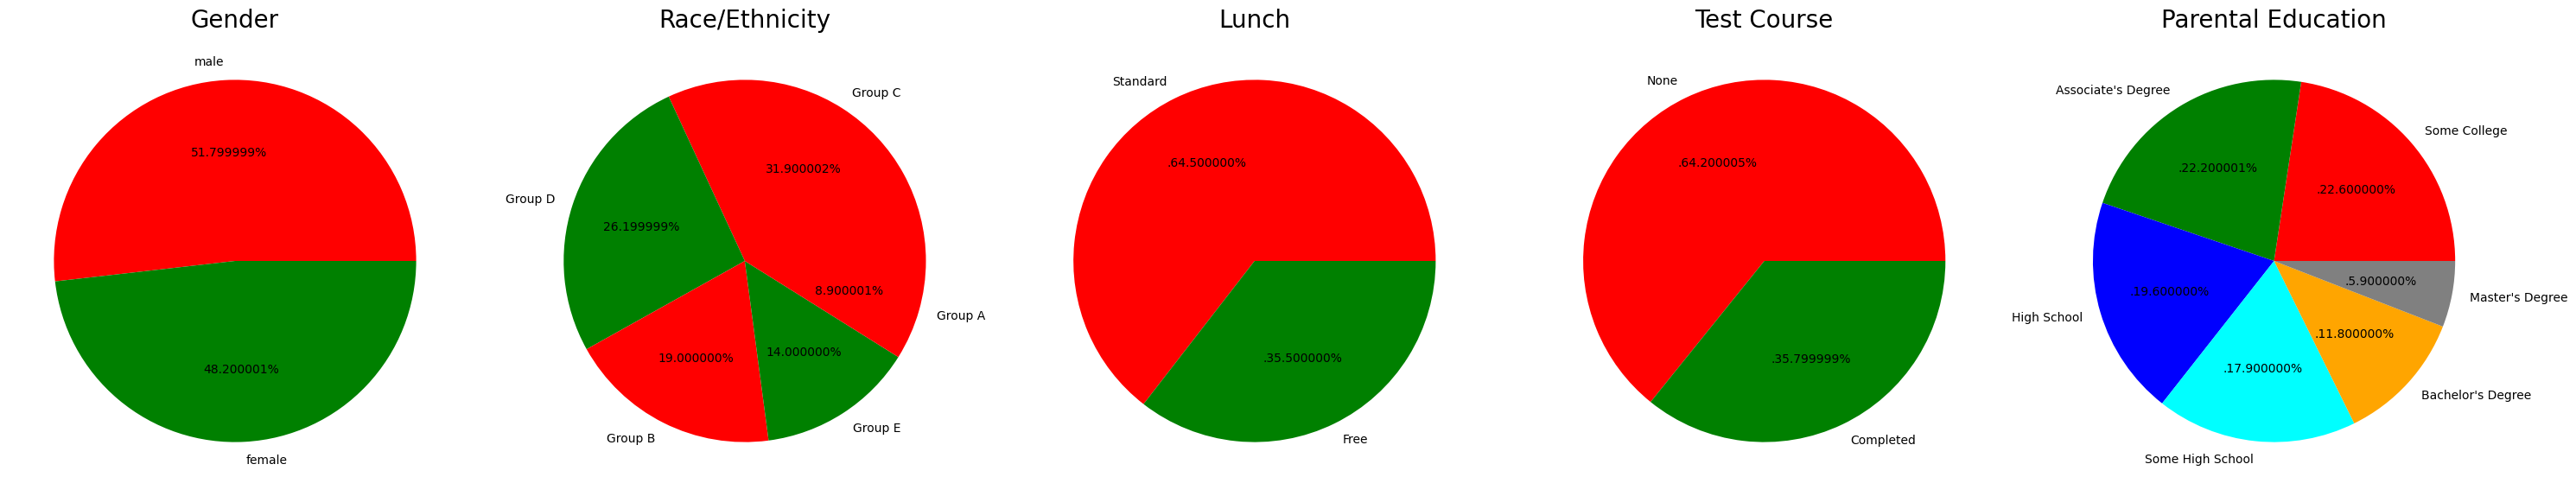

In [24]:
plt.rcParams['figure.figsize']=(30,12)
plt.subplot(1,5,1)
size=df['gender'].value_counts()
labels=['male','female']
colors=['red','green']
plt.pie(size,labels=labels,colors=colors,autopct='%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')


plt.subplot(1,5,2)
size=df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']
plt.pie(size,labels=labels,colors=colors,autopct='%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')

plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']
plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']
plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']
plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()


### Insights

- The number of **male and female students** in the dataset is **almost equal**.
- The **highest number of students** belong to **Group C**.
- Students who receive a **standard lunch** are greater in number compared to those with free/reduced lunch.
- The number of students who **have not enrolled in any test preparation course** is higher.
- The most common parental education level is **"Some College"**, followed closely by **"Associate's Degree"**.

## 4.4 Feature-wise Visualization

### 4.4.1 Gender Column

#### Distribution of Gender
This analysis focuses on understanding the distribution of male and female students in the dataset.

#### Impact of Gender on Student Performance
In this section, we analyze whether **gender has any impact on students’ academic performance** by comparing exam scores across genders using appropriate visualizations.



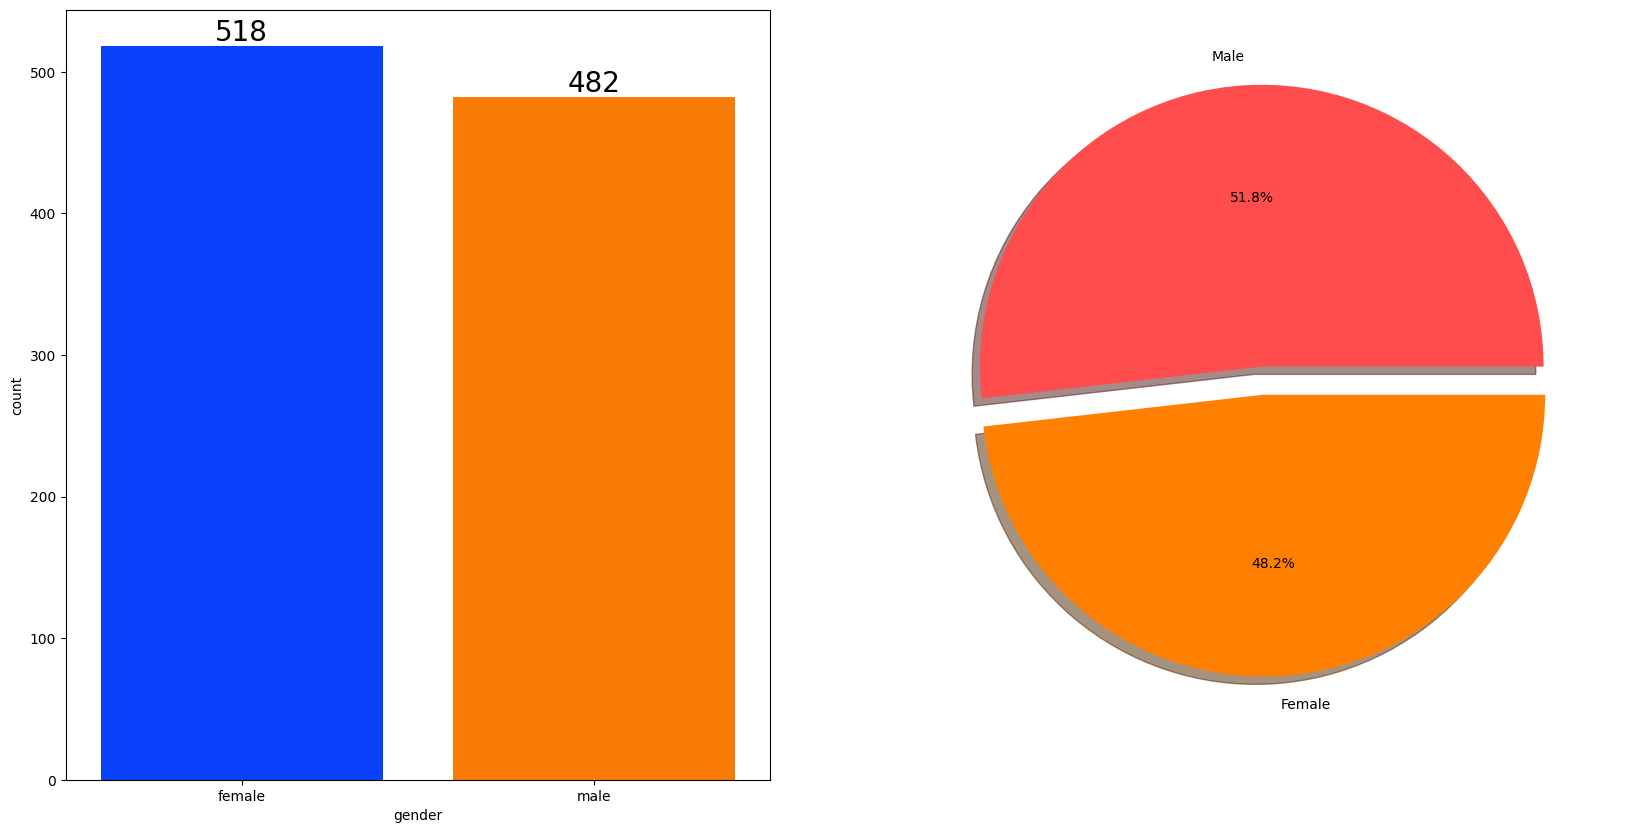

In [25]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0.1,0.0],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

## Insights

- The dataset has a **balanced gender distribution**, with **female students numbering 518 (48%)** and **male students numbering 482 (52%)**.

### Bivariate Analysis  
**Does gender have any impact on students' performance?**

In this analysis, we examine the relationship between **gender** and **students' academic performance** by comparing exam scores across male and female students using visualizations and summary statistics.


In [26]:
gender_group = df.groupby('gender')[['math_score', 'reading_score', 'writing_score','average']].mean()
gender_group

,math_score,reading_score,writing_score,average
gender,,,,
female,63.633205,72.608108,72.467181,69.569498
male,68.728216,65.473029,63.311203,65.837483


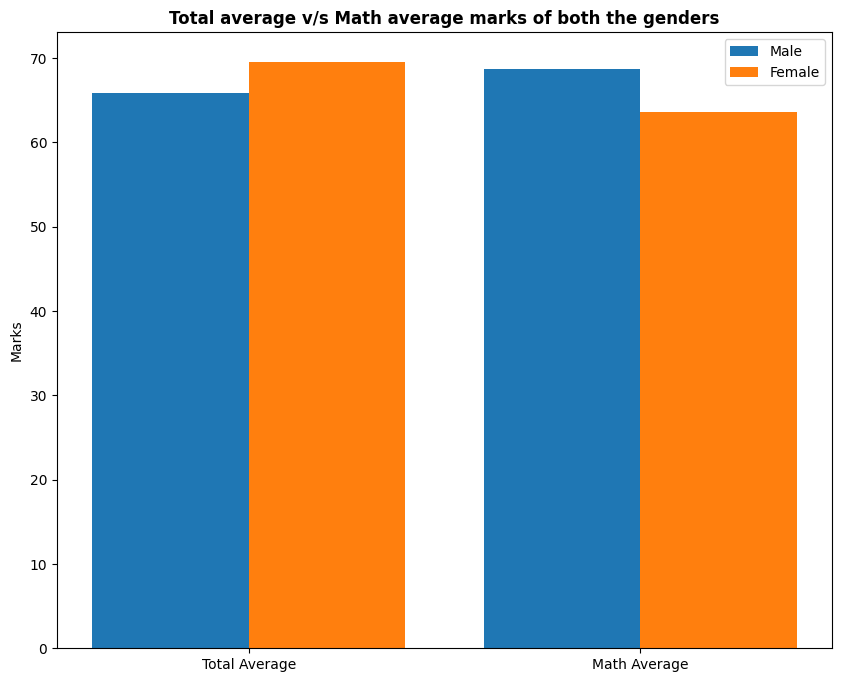

In [27]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group['average'][0], gender_group['math_score'][0]]
male_scores = [gender_group['average'][1], gender_group['math_score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

## Insights

- On average, **female students have a better overall score** compared to male students.
- However, **male students tend to score higher in Mathematics**.

---

### 4.4.2 Race/Ethnicity Column

#### Group-wise Distribution
This section analyzes the distribution of students across different **race/ethnicity groups**.

#### Impact of Race/Ethnicity on Student Performance
Here, we examine whether **race/ethnicity has any influence on students’ academic performance** by comparing exam sc


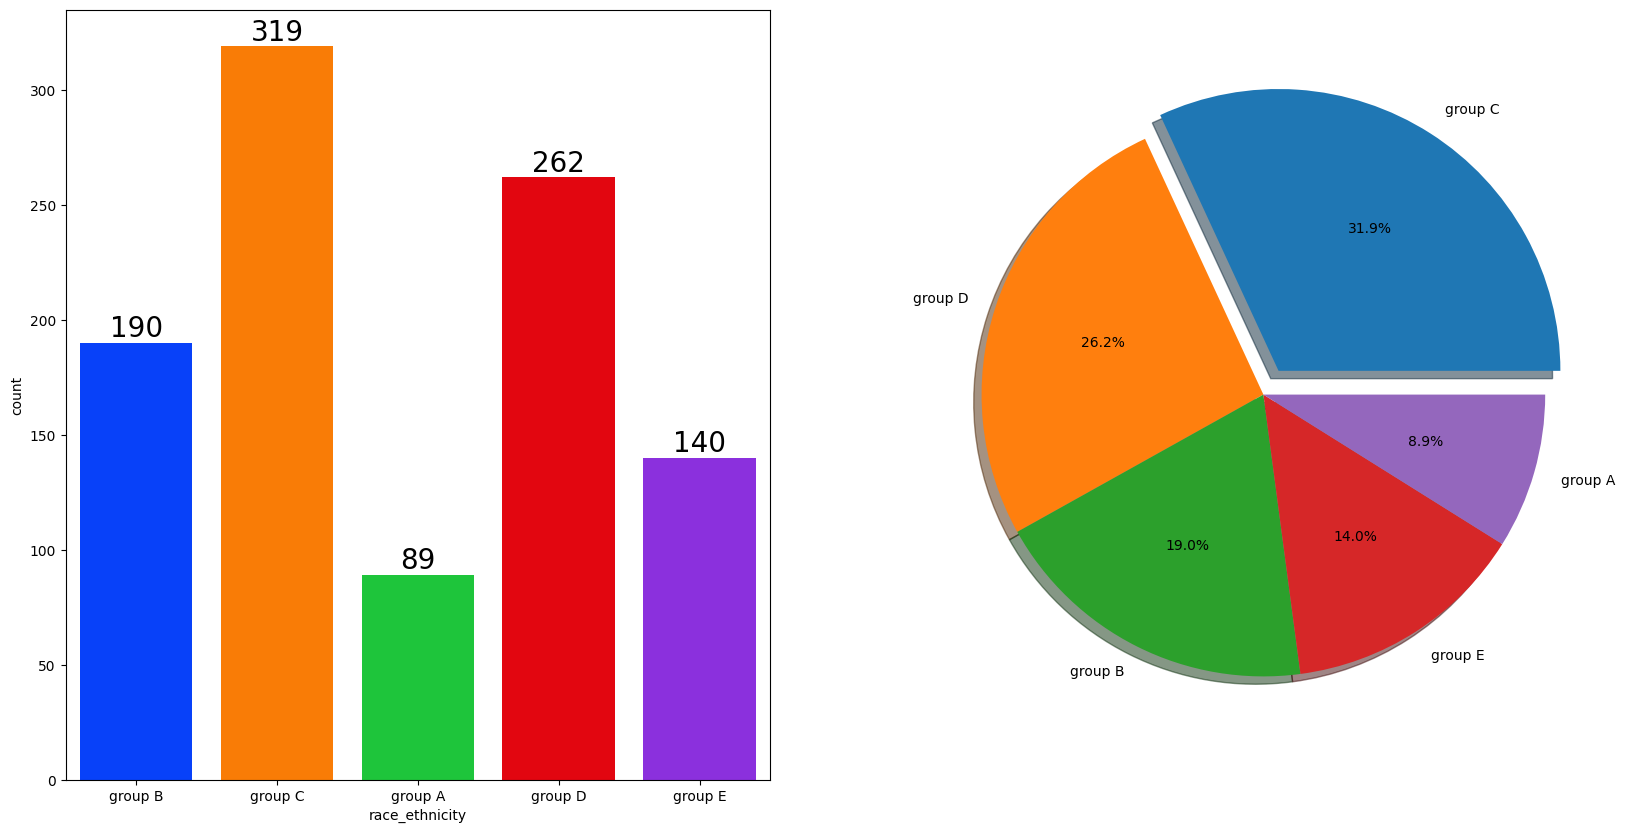

In [28]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette='bright',ax=ax[0],saturation=0.95)
for i in ax[0].containers:
    ax[0].bar_label(i,color='black',size=20)
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()   

## Insights

- Most of the students belong to **Group C** and **Group D**.
- The **lowest number of students** belong to **Group A**.

---

### Bivariate Analysis  
**Does race/ethnicity have any impact on students' performance?**

In this analysis, we examine the relationship between **race/ethnicity** and **students' academic performance** by comparing exam scores across different groups.


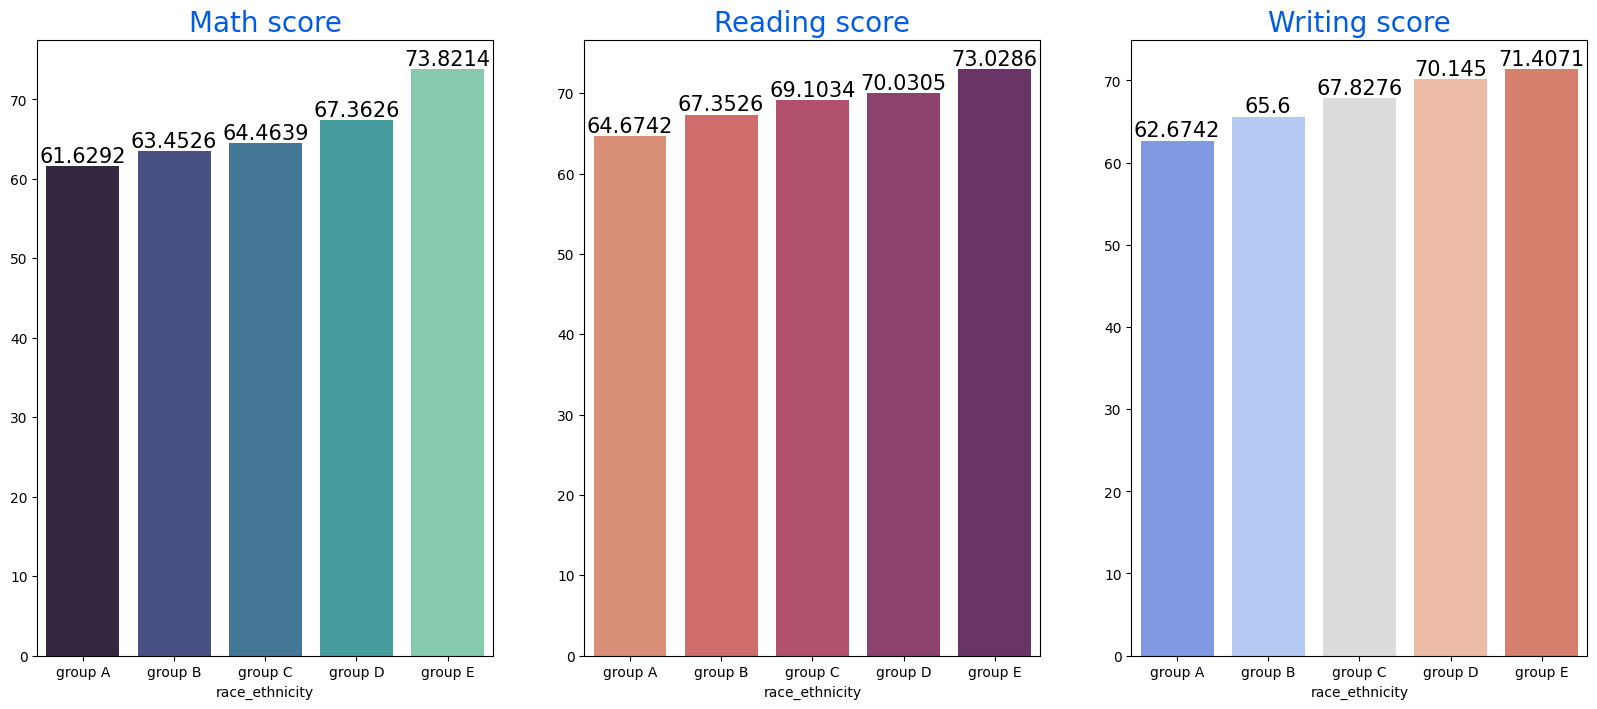

In [29]:
Group_data2=df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

## Insights

- Students from **Group E** have scored the **highest marks** across subjects.
- Students from **Group A** have scored the **lowest marks**.
- Students belonging to a **lower socioeconomic status** tend to have a **lower average score** in all subjects.

---

### 4.4.3 Parental Level of Education Column

#### Educational Background of Students' Parents
This section explores the **educational qualifications of students' parents**.

#### Impact of Parental Education on Student Performance
Here, we analyze whether **parental education has any influence on students’ academic performance** by comparing exam scores across different education levels.


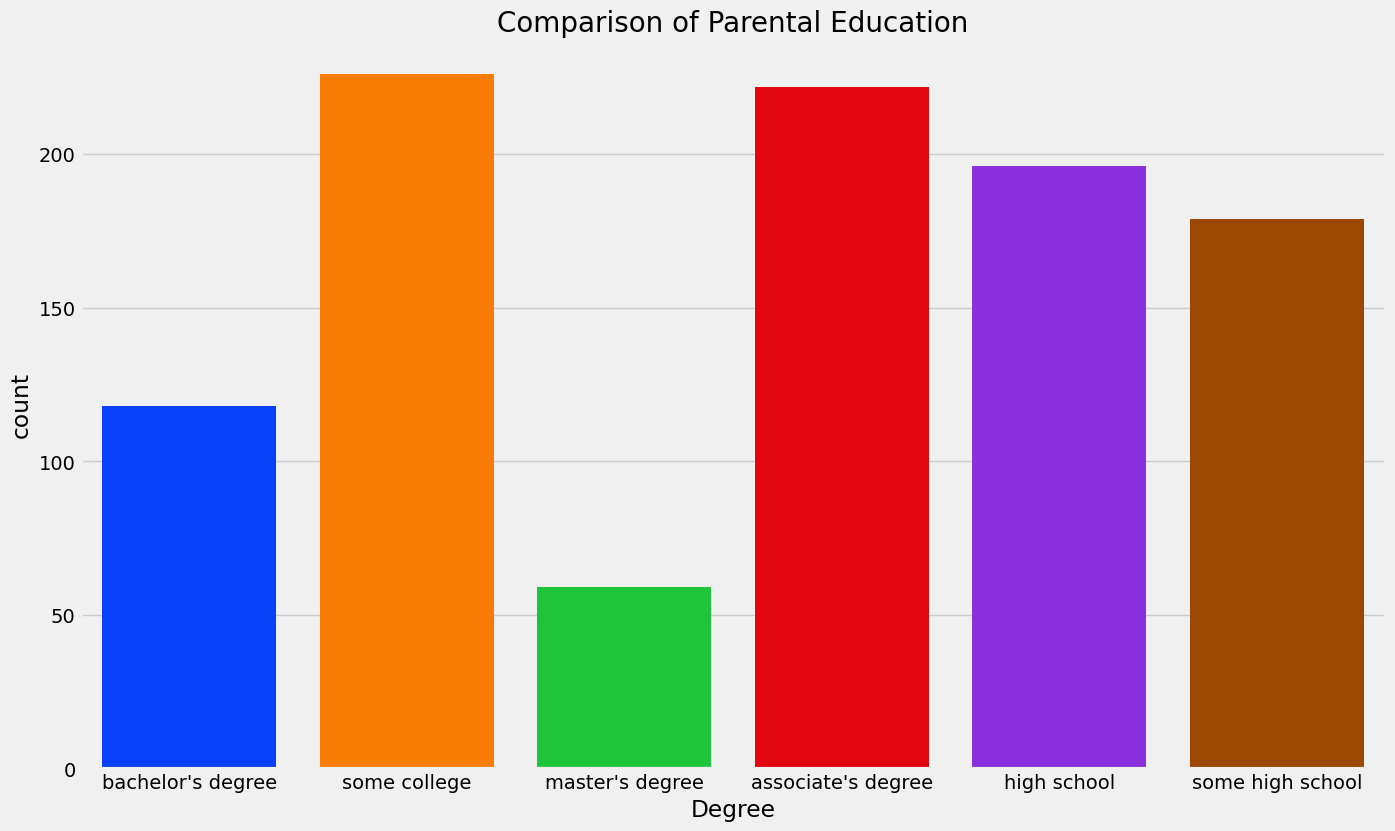

In [31]:
plt.rcParams['figure.figsize']=(15,9)
plt.style.use('fivethirtyeight')
sns.countplot(x=df['parental_level_of_education'],data=df,palette='bright',saturation=0.95)
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

## Insights

- The **largest number of parents** have an education level of **"Some College"**.

---

### Bivariate Analysis  
**Does parental education have any impact on students' performance?**

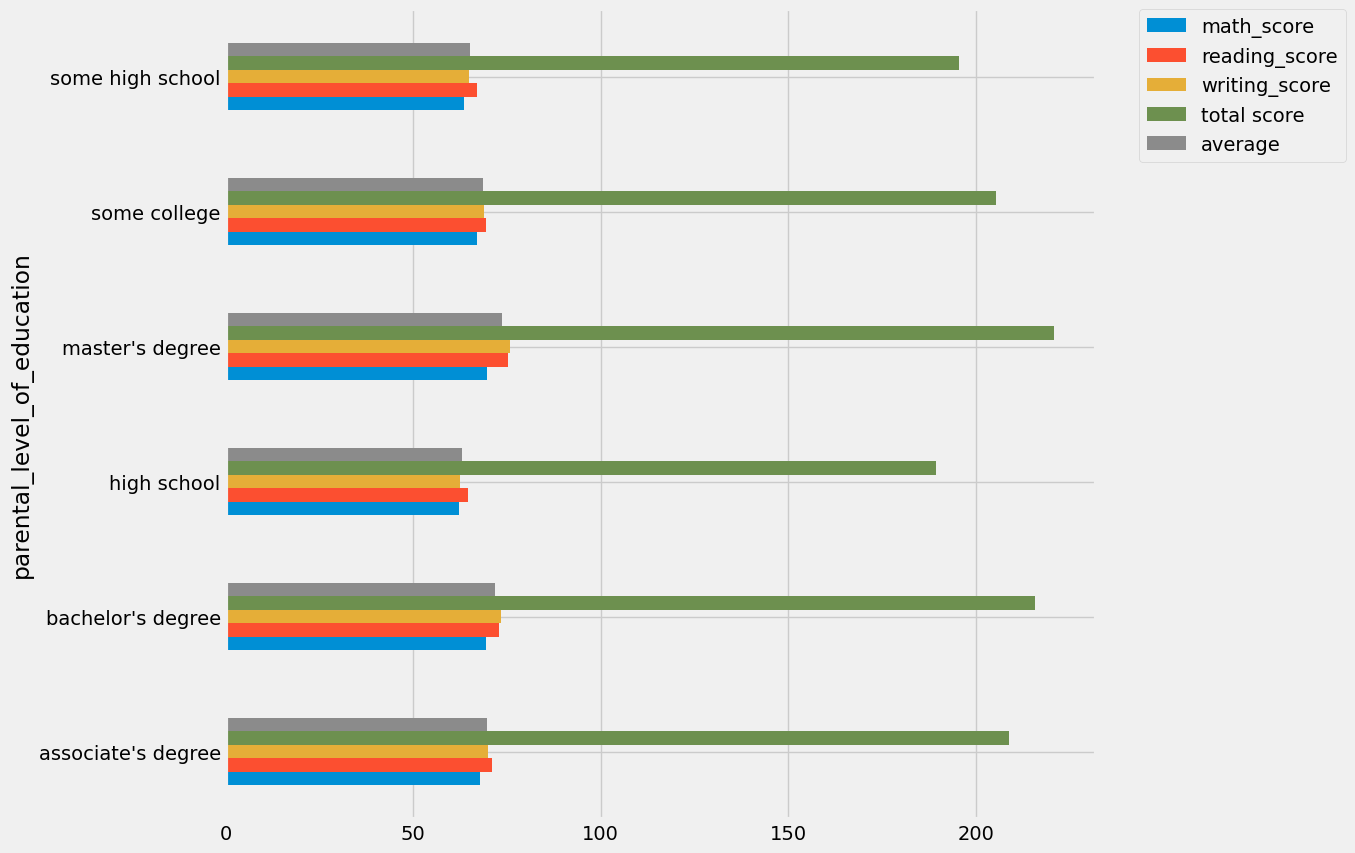

In [35]:
df.groupby('parental_level_of_education').mean(numeric_only=True).plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

## Insights

- The score of students whose parents possess **Master’s** and **Bachelor’s** level education is higher than others.

---

### 4.4.4 Lunch Column

#### Which type of lunch is most common among students?
This section examines the distribution of lunch types among students.

#### What is the effect of lunch type on test results?
Here, we analyze how different lunch types influence students’ test performance.


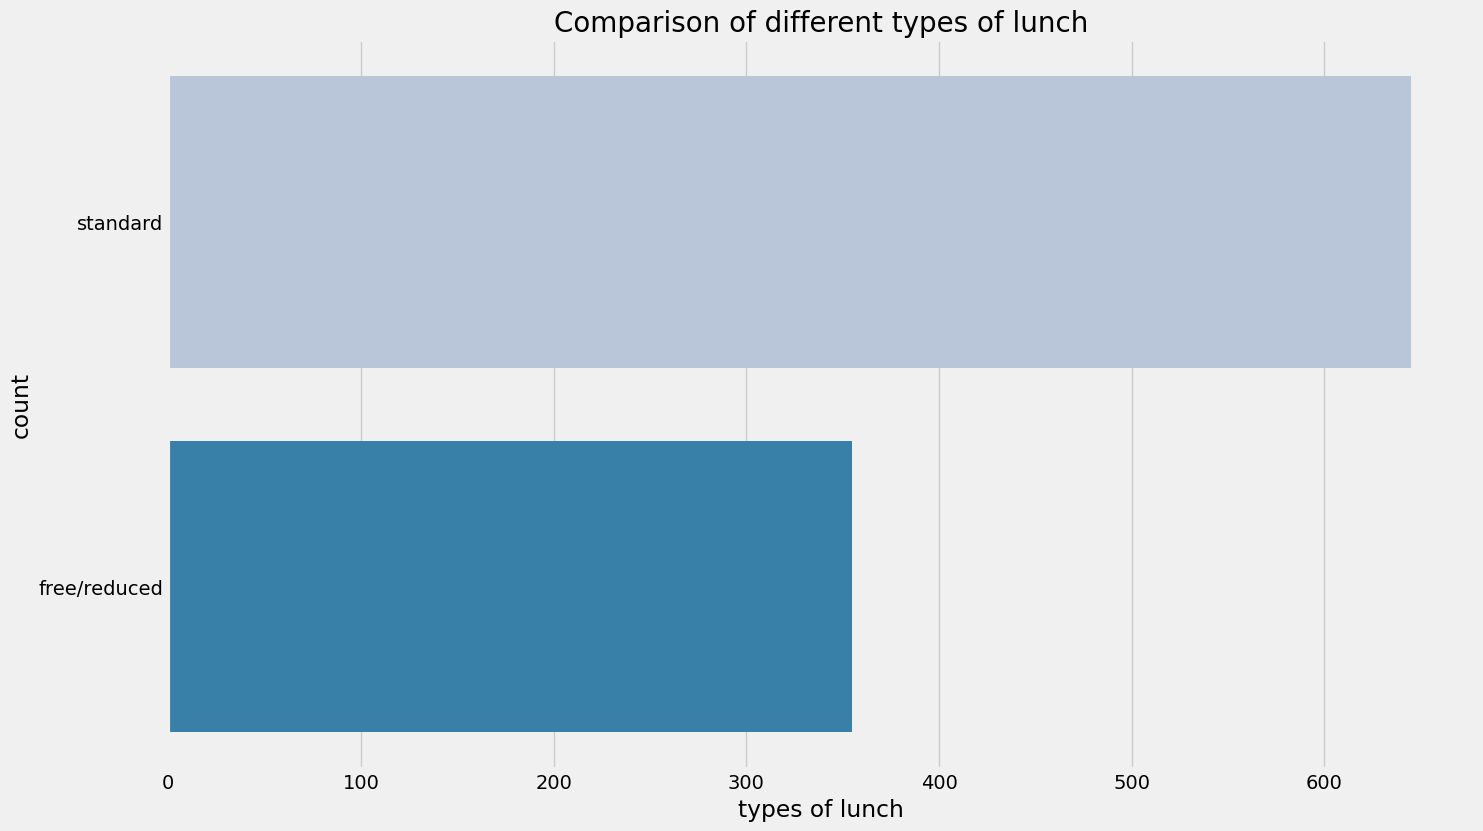

In [37]:
plt.rcParams['figure.figsize'] = (15, 9)
# plt.style.use('seaborn-talk')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

## Insights

- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

---

### 4.4.5 Test Preparation Course Column

#### Which type of lunch is most common amoung students ?
#### Is Test prepration course has any impact on student's performance ?

---

### Bivariate Analysis  
( Is Test prepration course has any impact on student's performance ? )


<Axes: xlabel='lunch', ylabel='writing_score'>

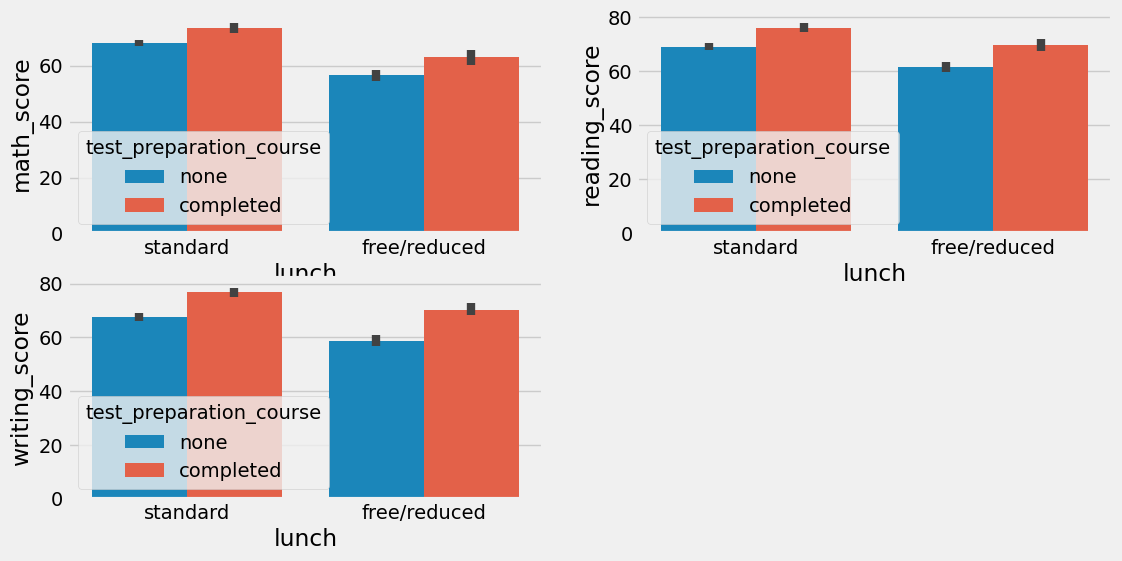

In [38]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])

## Insights

- Students who have completed the **Test Prepration Course** have scores higher in all three categories than those who haven't taken the course


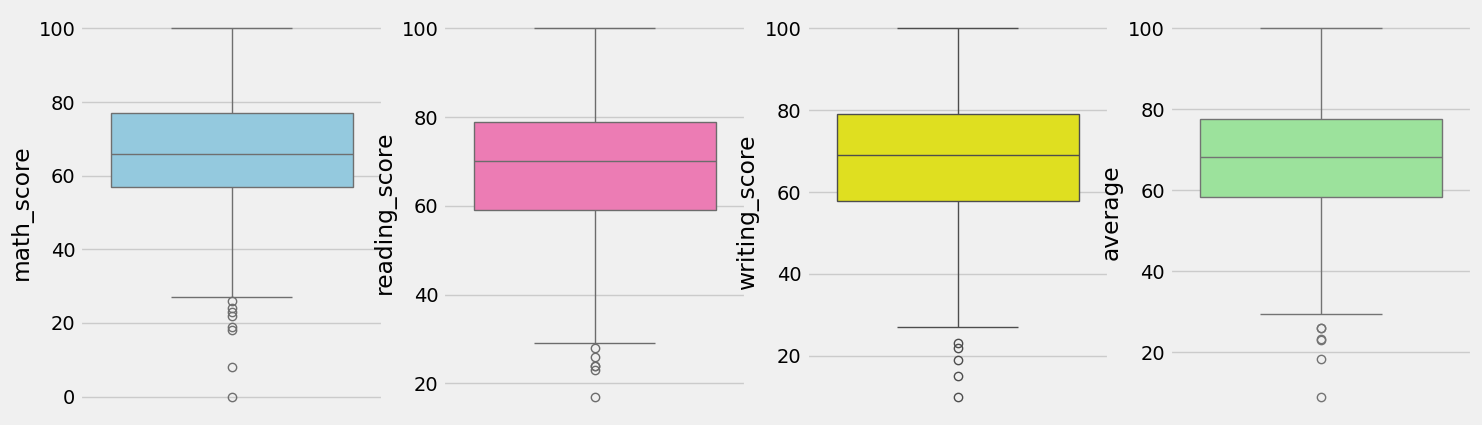

In [40]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

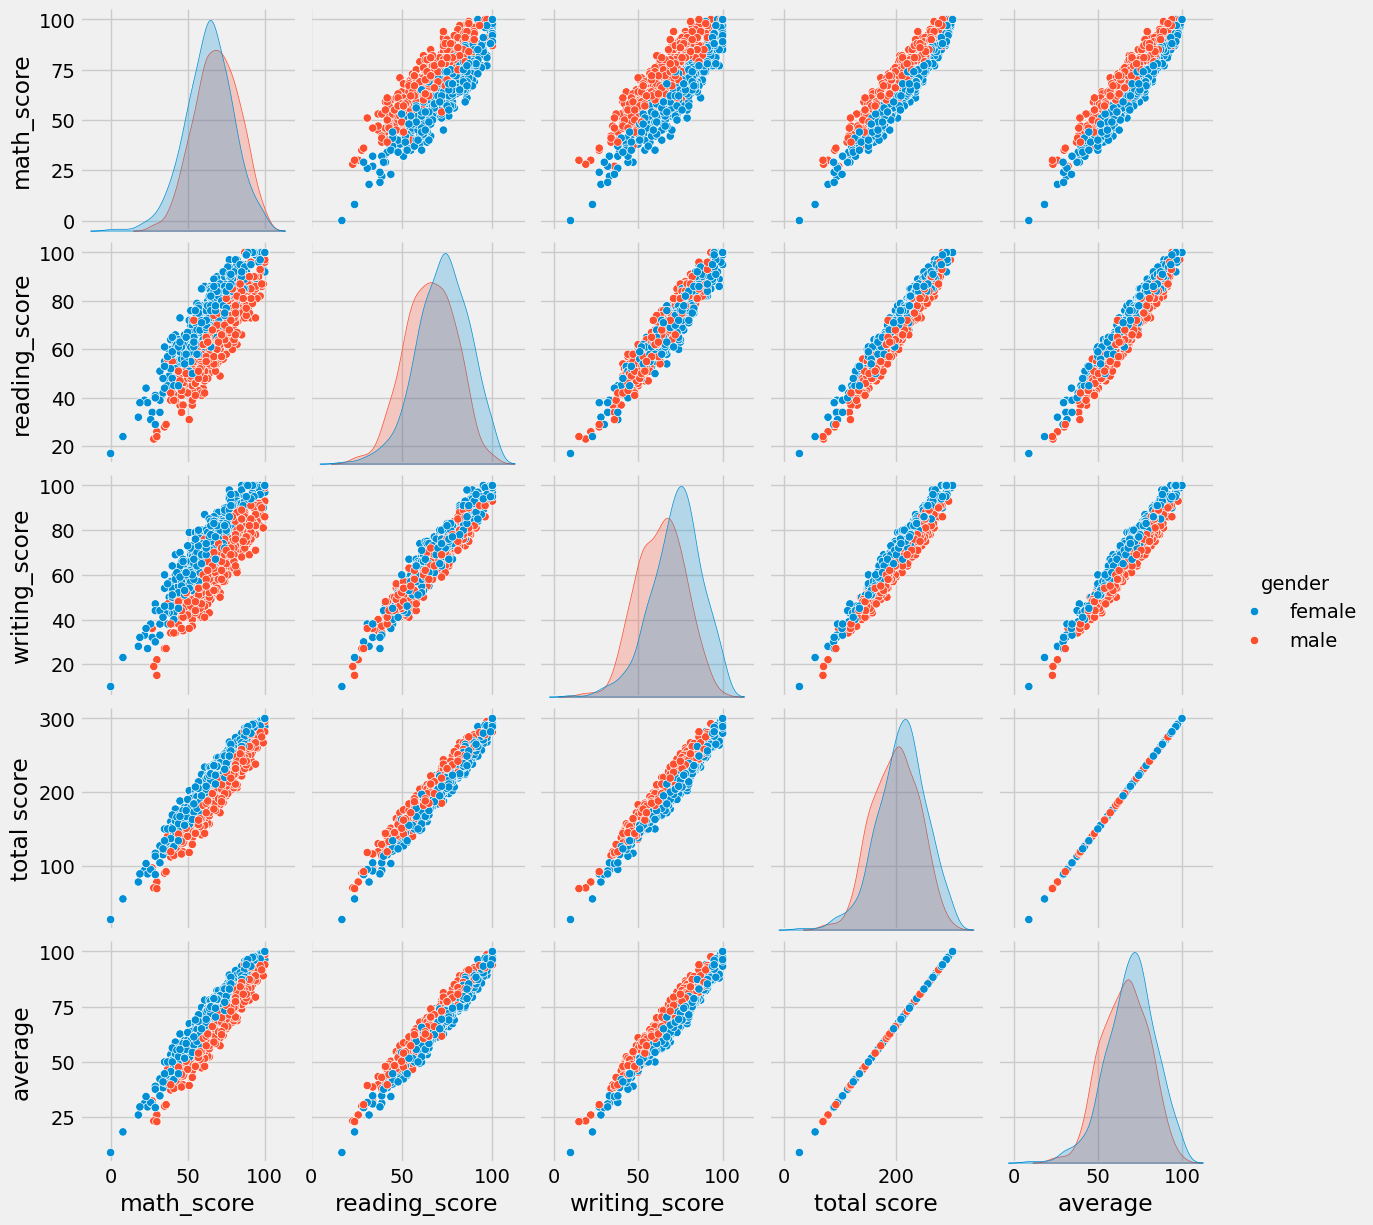

In [41]:
sns.pairplot(df,hue = 'gender')
plt.show()

## Insights

- From the above plot, it is clear that all the scores increase **linearly with each other**.

---

## 5. Conclusions

- Student performance is related to **lunch type**, **race/ethnicity**, and **parental level of education**.
- **Female students** lead in pass percentage and are also **top scorers** overall.
- Student performance is **not strongly related** to the test preparation course.
- However, **finishing the test preparation course is beneficial** for improving scores.
